# Different Roughness models

`refnx` has a variety of different interfacial roughness models available, over and above the default [Nevot-Croce][1] roughness formalism. The Nevot-Croce formalism is equivalent to a Gaussian roughness between two layers.

When a different roughness model is used the calculation no longer uses the Nevot-Croce damping factor. Instead, the entire scattering length density profile is micro-sliced.

[1]: L. Nevot and P. Croce, Rev. Phys. Appl. 15, 761 (1980)

The definitions for all the roughness models are round in the following papers:

Svechnikov, M.; Pariev, D.; Nechay, A.; Salashchenko, N.; Chkhalo, N.; Vainer, Y. & Gaman, D.,
"Extended model for the reconstruction of periodic multilayers from extreme ultraviolet and X-ray reflectivity data",
Journal of Applied Crystallography, 2017, 50, 1428-1440

Stearns, D. G. J. Appl. Phys., 1989, 65, 491–506.
D. Bahr; W. Press; R. Jebasinski; S. Mantl, Phys. Rev. B, 1993, 47 (8), 4385


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from refnx.reflect import Slab, SLD

# the following are the different interfacial roughnesses that are available
from refnx.reflect import Erf, Linear, Exponential, Tanh, Sinusoidal, Step

A comparison of the different roughness models can be achieved with only the fronting and backing slabs, with a roughness in between

In [2]:
air = SLD(0.0)
d2o = SLD(6.36)

Let's create SLD plots corresponding to each of the different roughness models. In the following graph we're going to offset the SLD values vertically, to permit an easier comparison between the plots. Please note the horizontal offset we apply to the default roughness model, `rough_model=None`, which corresponds to Nevot-Croce roughness. This horizontal offset is because of the microslicing that's necessary for all the other roughness models and has no impact on the overall reflectivity calculation.

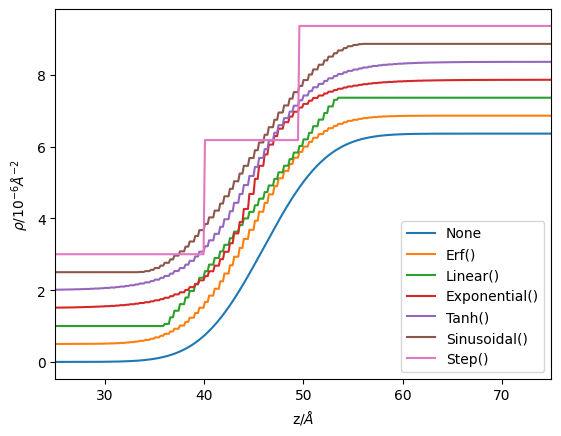

In [3]:
# Create the structure, with different forms of interfacial roughness
fig, ax = plt.subplots(1)

for i, rough_model in enumerate(
    [None, Erf, Linear, Exponential, Tanh, Sinusoidal, Step]
):
    if rough_model is not None:
        interface = rough_model()
    else:
        # using None for the interface roughness results in the Nevot-Croce default
        interface = None

    # Here we create the d2o slab via the Slab constructor, which allows you to specify what roughness type you want to use via the `interface` keyword.
    s = air(0, 0) | Slab(0, d2o, 5, interface=interface)

    # you could also set the interfaces attribute directly
    # s[-1].interfaces = interface

    zed, sld = s.sld_profile(z=np.linspace(-40, 100, 1001))
    if rough_model == None:
        zed += 46
    ax.plot(zed, sld + i * 0.5, label=repr(interface))

ax.set_xlim(25, 75)
ax.set_xlabel("z/$\\AA$")
ax.set_ylabel("$\\rho / 10^{-6} \\AA^{-2}$")
plt.legend();